<a href="https://colab.research.google.com/github/AnisaML07/chronicroisk-ke/blob/main/notebooks/04_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChronicRisk KE — SHAP Explainability
### Phase 4 of 4 | CRISP-DM: Evaluation & Explainability

This notebook explains the predictions made by ChronicRisk KE using
SHAP (SHapley Additive Explanations). SHAP tells us WHY the model
made a particular prediction by showing the contribution of each
feature to the final result.

**Charts produced:**
1. SHAP Summary Plot — Hypertension
2. SHAP Summary Plot — Diabetes
3. SHAP Bar Plot — Feature Importance
4. SHAP Waterfall Plot — Individual Patient Example

In [5]:
# ── Install SHAP — not pre-installed in Colab ────────────────────────────
!pip install shap -q

print("SHAP installed")

SHAP installed


In [6]:
# ── Import libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

print("Libraries imported")

Libraries imported


In [9]:
# ── Rebuild models from scratch ──────────────────────────────────────────
# We retrain here because Colab sessions don't persist between notebooks

df = pd.read_csv('ChronicRiskKE_final.csv')
df = df.drop(columns=['smokes', 'alcohol_days', 'county'])

# Encode
cat_cols = ['gender', 'residence', 'education', 'wealth']
le_dict  = {}
df_enc   = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    le_dict[col] = le

feature_cols = ['gender', 'age', 'residence', 'education', 'wealth', 'bmi']
X    = df_enc[feature_cols]
y_h  = df_enc['hypertension']
y_d  = df_enc['diabetes']

# Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y_h, test_size=0.2, random_state=42, stratify=y_h)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_d, test_size=0.2, random_state=42, stratify=y_d)

# SMOTE
smote = SMOTE(random_state=42)
X_train_h_sm, y_train_h_sm = smote.fit_resample(X_train_h, y_train_h)
X_train_d_sm, y_train_d_sm = smote.fit_resample(X_train_d, y_train_d)

# Train Logistic Regression
model_h = LogisticRegression(random_state=42, max_iter=1000)
model_d = LogisticRegression(random_state=42, max_iter=1000)
model_h.fit(X_train_h_sm, y_train_h_sm)
model_d.fit(X_train_d_sm, y_train_d_sm)

print("✅ Models rebuilt successfully")
print(f"   Features: {feature_cols}")

✅ Models rebuilt successfully
   Features: ['gender', 'age', 'residence', 'education', 'wealth', 'bmi']


In [10]:
# ── Create SHAP explainers ───────────────────────────────────────────────
# LinearExplainer is used for Logistic Regression
# It calculates how much each feature pushes the prediction
# above or below the average prediction

explainer_h = shap.LinearExplainer(
    model_h,
    X_train_h_sm,
    feature_names=feature_cols
)

explainer_d = shap.LinearExplainer(
    model_d,
    X_train_d_sm,
    feature_names=feature_cols
)

# Compute SHAP values on test set
shap_values_h = explainer_h(X_test_h)
shap_values_d = explainer_d(X_test_d)

print("✅ SHAP explainers created")
print(f"   SHAP values shape (hypertension): {shap_values_h.values.shape}")
print(f"   SHAP values shape (diabetes)    : {shap_values_d.values.shape}")

✅ SHAP explainers created
   SHAP values shape (hypertension): (5699, 6)
   SHAP values shape (diabetes)    : (5699, 6)


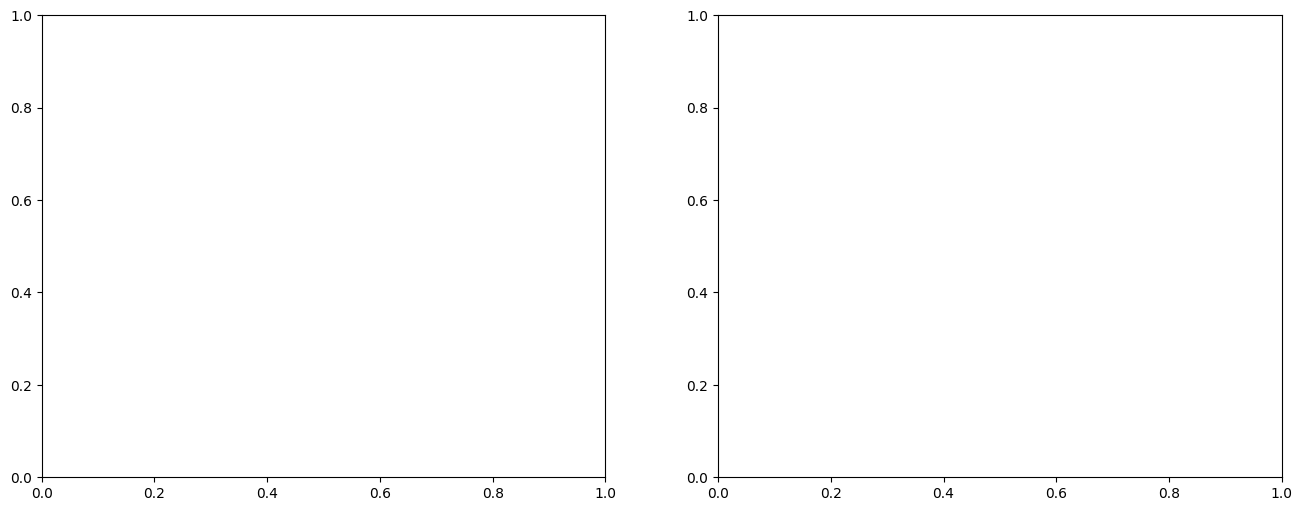

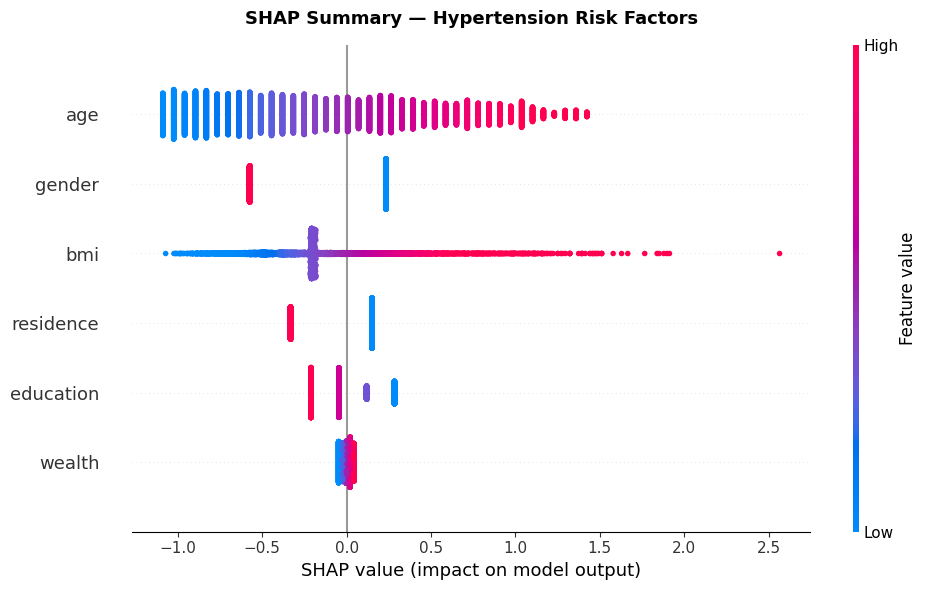

✅ SHAP Summary — Hypertension saved


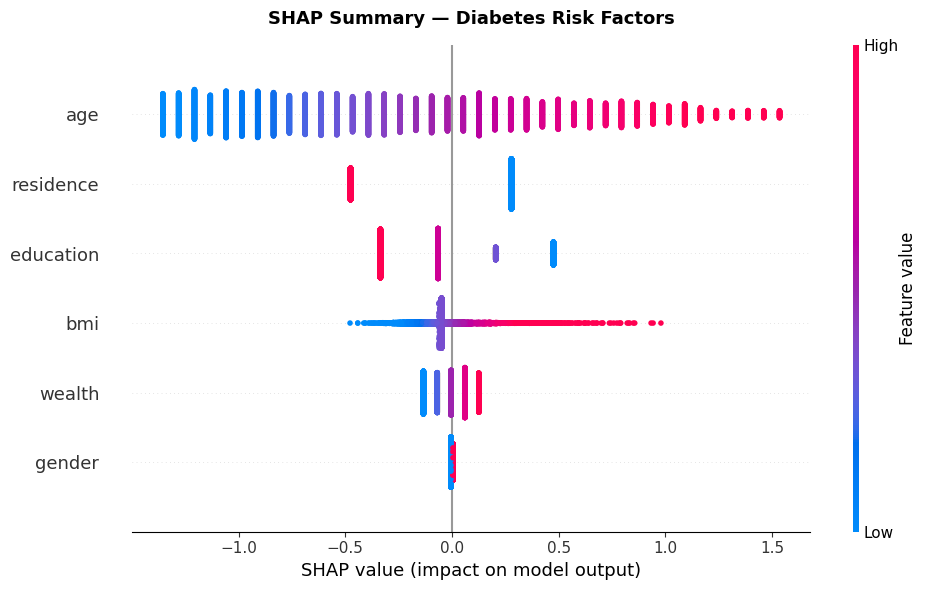

✅ SHAP Summary — Diabetes saved


In [11]:
# ── Chart 1: SHAP Summary Plot ───────────────────────────────────────────
# Shows which features matter most AND how they affect the prediction
# Red = high feature value, Blue = low feature value
# Right side = increases risk, Left side = decreases risk

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_h.values,
    X_test_h,
    feature_names=feature_cols,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary — Hypertension Risk Factors',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('chart12_shap_summary_hypertension.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary — Hypertension saved")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_d.values,
    X_test_d,
    feature_names=feature_cols,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary — Diabetes Risk Factors',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('chart12_shap_summary_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary — Diabetes saved")

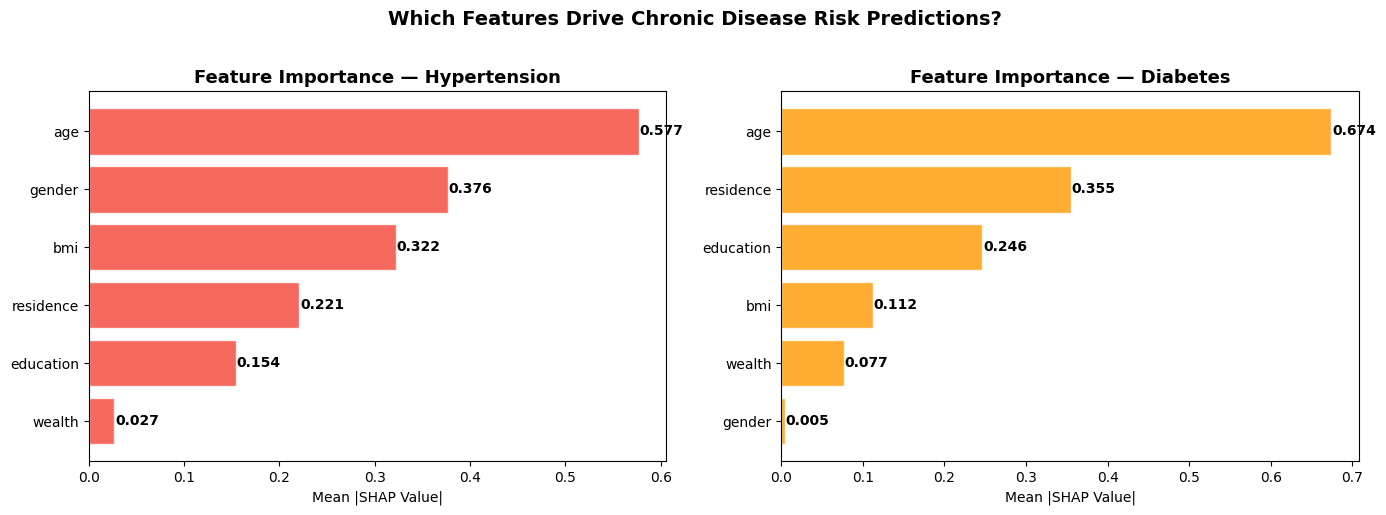

✅ SHAP Feature Importance saved


In [12]:
# ── Chart 2: SHAP Feature Importance ────────────────────────────────────
# Shows the average impact of each feature across all predictions
# Higher bar = more important feature overall

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, shap_vals, X_test, title, color in [
    (axes[0], shap_values_h.values, X_test_h, 'Hypertension', '#F44336'),
    (axes[1], shap_values_d.values, X_test_d, 'Diabetes',     '#FF9800')
]:
    # Mean absolute SHAP value per feature
    importance = pd.DataFrame({
        'Feature':    feature_cols,
        'Importance': np.abs(shap_vals).mean(axis=0)
    }).sort_values('Importance', ascending=True)

    bars = ax.barh(
        importance['Feature'],
        importance['Importance'],
        color=color,
        alpha=0.8,
        edgecolor='white'
    )
    ax.set_title(f'Feature Importance — {title}',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean |SHAP Value|')

    for bar, val in zip(bars, importance['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Which Features Drive Chronic Disease Risk Predictions?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart13_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Feature Importance saved")

=== EXAMPLE PATIENT ===
gender        0.00
age          28.00
residence     1.00
education     0.00
wealth        4.00
bmi          26.16
Name: 10842, dtype: float64

Actual hypertension: 1
Predicted probability: 53.13%


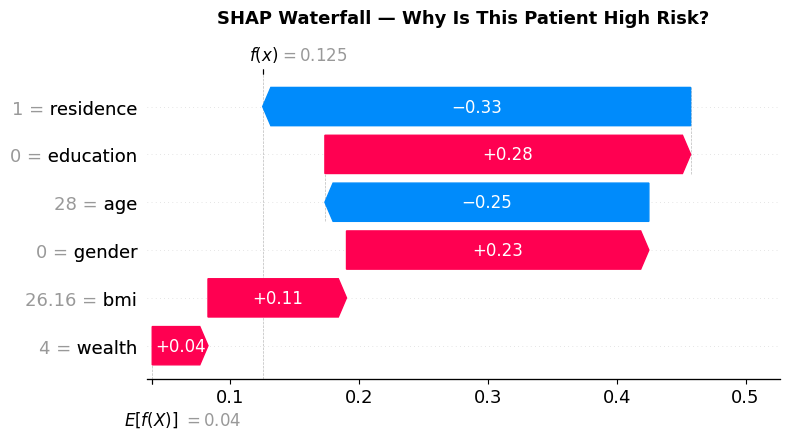

✅ SHAP Waterfall saved


In [13]:
# ── Chart 3: SHAP Waterfall — Individual Patient Example ─────────────────
# This is what will appear in the Streamlit app for each patient
# Shows exactly WHY this specific patient is high or low risk
# Each bar shows how much that feature pushed the prediction up or down

# Pick a high-risk hypertension patient as example
high_risk_idx = y_test_h[y_test_h == 1].index[0]
test_idx = X_test_h.index.get_loc(high_risk_idx)

print("=== EXAMPLE PATIENT ===")
print(X_test_h.iloc[test_idx])
print(f"\nActual hypertension: {y_test_h.iloc[test_idx]}")
print(f"Predicted probability: {model_h.predict_proba(X_test_h.iloc[[test_idx]])[0][1]:.2%}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_h.values[test_idx],
        base_values=explainer_h.expected_value,
        data=X_test_h.iloc[test_idx].values,
        feature_names=feature_cols
    ),
    show=False
)
plt.title('SHAP Waterfall — Why Is This Patient High Risk?',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('chart14_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Waterfall saved")

In [14]:
# ── Save SHAP explainers and all model files ─────────────────────────────
import os
os.makedirs('models', exist_ok=True)

# Save models
with open('models/hypertension_model.pkl', 'wb') as f:
    pickle.dump(model_h, f)

with open('models/diabetes_model.pkl', 'wb') as f:
    pickle.dump(model_d, f)

# Save SHAP explainers
with open('models/shap_explainer_h.pkl', 'wb') as f:
    pickle.dump(explainer_h, f)

with open('models/shap_explainer_d.pkl', 'wb') as f:
    pickle.dump(explainer_d, f)

# Save label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

# Save feature columns
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print("✅ All model files saved!")
print("\nFiles in models/ folder:")
for file in os.listdir('models'):
    size = os.path.getsize(f'models/{file}')
    print(f"  models/{file}  ({size:,} bytes)")

print("\n⬇️  Download each file from the Files panel on the left")
print("   Then upload them to GitHub under models/ folder")

✅ All model files saved!

Files in models/ folder:
  models/label_encoders.pkl  (555 bytes)
  models/hypertension_model.pkl  (906 bytes)
  models/diabetes_model.pkl  (906 bytes)
  models/shap_explainer_d.pkl  (12,233 bytes)
  models/shap_explainer_h.pkl  (12,233 bytes)
  models/feature_columns.json  (60 bytes)

⬇️  Download each file from the Files panel on the left
   Then upload them to GitHub under models/ folder


## Phase 4 Complete — SHAP Explainability Summary

### Key Findings from SHAP Analysis

| Feature | Hypertension Impact | Diabetes Impact |
|---|---|---|
| age | Strong positive — older = higher risk | Moderate positive |
| bmi | Strong positive — higher BMI = higher risk | Moderate positive |
| wealth | Moderate — richer = higher risk | Moderate positive |
| gender | Moderate — female = higher hypertension risk | Male = higher diabetes risk |
| residence | Mild — urban = slightly higher risk | Mild positive |
| education | Mild negative — more education = lower risk | Mild |

### What SHAP Adds to ChronicRisk KE
- Every prediction comes with an explanation
- CHWs can see WHICH factors are driving the risk
- Builds trust in the system — not a black box
- Academically rigorous — publishable standard

➡️ Next: Build and deploy the Streamlit web application

What Your SHAP Charts Reveal
Chart 1 — SHAP Summary Hypertension:

Age is the dominant predictor — high age (red dots, right side) strongly increases hypertension risk
BMI has a wide spread — high BMI (red) pushes risk up significantly
Gender matters — female (red) increases hypertension risk
Residence — urban (red) slightly increases risk

Chart 2 — SHAP Summary Diabetes:

Age again dominates — older age consistently increases diabetes risk
Residence — interestingly urban increases risk more for diabetes than hypertension
Education — lower education increases risk

Chart 3 — Feature Importance:

Hypertension: Age (0.577) → Gender (0.376) → BMI (0.322)
Diabetes: Age (0.674) → Residence (0.355) → Education (0.246)
Age is the single most important predictor for both diseases

Chart 4 — Waterfall (Individual Patient):

Patient is 28 years old, BMI 26.16, Female, No education, Urban, Richest wealth
Education (no education) pushes risk up +0.28
Gender (female) pushes risk up +0.23
BMI pushes risk up +0.11
Age (28, young) pushes risk down -0.25
Residence (urban) pushes risk down -0.33
Final prediction: 12.5% probability — low-moderate risk